In [ ]:
from FIT_python.Visualisations.plot_style import apply_style
apply_style()


In [ ]:
# Original function for calculating overlap
def is_overlapping(p, mu, pooled_cov):
    chi_square_val = np.sqrt(chi2.ppf(p, df=2))
    pairs = itertools.combinations(range(len(mu)), 2)
    for i, j in pairs:
        diff = mu[i] - mu[j]
        dist = np.linalg.norm(diff)
        radius = chi_square_val * np.sqrt(np.trace(pooled_cov) / 2)
        if dist <= (2 * radius):
            return True
    return False

In [7]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import chi2

def parse_list(s):
    """Parst einen String wie '[1.0, 2.0, ...]' in ein numpy-Array."""
    try:
        return np.array(ast.literal_eval(s), dtype=float)
    except:
        return np.array([], dtype=float)

def compute_overlap_jsl_style(row, p=0.5):
    """
    Berechnet die Überlappung analog zur JSL-Funktion:
      - Radius A = chi_val * std(distances A zum Zentrum)
      - Radius B = chi_val * std(distances B zum Zentrum)
      - Überlappung, wenn Abstand Zentren <= RadiusA + RadiusB
    """
    # 1) Punkte einlesen
    xa = parse_list(row['coords_a_x'])
    ya = parse_list(row['coords_a_y'])
    xb = parse_list(row['coords_b_x'])
    yb = parse_list(row['coords_b_y'])
    # 2) Validität prüfen
    if len(xa) < 2 or len(xb) < 2 or len(xa)!=len(ya) or len(xb)!=len(yb):
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    # 3) Zentren berechnen
    mu_a = pts_a.mean(axis=0)
    mu_b = pts_b.mean(axis=0)
    # 4) Abstände der Punkte zu ihrem Zentrum
    dist_a = np.linalg.norm(pts_a - mu_a, axis=1)
    dist_b = np.linalg.norm(pts_b - mu_b, axis=1)
    # 5) Standardabweichungen dieser Abstände (entspricht stdMat in JSL)
    std_a = dist_a.std(ddof=1)
    std_b = dist_b.std(ddof=1)
    # 6) Chi-Quadrat-Faktor
    chi_val = np.sqrt(chi2.ppf(p, df=2))
    # 7) Radien
    r1 = chi_val * std_a
    r2 = chi_val * std_b
    # 8) Abstand der Zentren
    center_dist = np.linalg.norm(mu_a - mu_b)
    # 9) Überlappungstest
    return center_dist <= (r1 + r2)

def main():
    # Pfade anpassen
    input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\eurasian_otter_all_results_combined.csv'
    output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\otter_results_with_ellipse_overlap2.csv'
    

    # 1) DataFrame einlesen (Strings behalten)
    df = pd.read_csv(input_csv, dtype=str)

    # 2) Neue Spalte berechnen
    df['ellipse_overlap'] = df.apply(compute_overlap_jsl_style, axis=1)

    # 3) Speichern
    df.to_csv(output_csv, index=False)
    print(f"Fertig! Ergebnisse mit Spalte 'ellipse_overlap' liegen in '{output_csv}'.")

if __name__ == '__main__':
    main()


Fertig! Ergebnisse mit Spalte 'ellipse_overlap' liegen in 'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\otter_results_with_ellipse_overlap2.csv'.


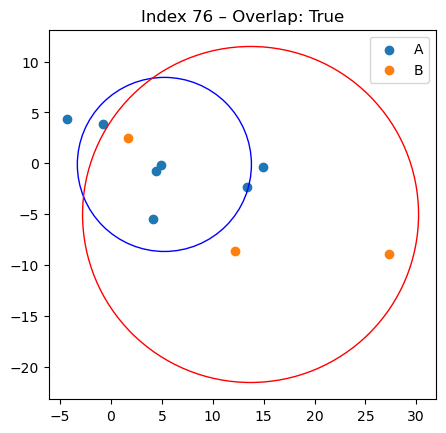

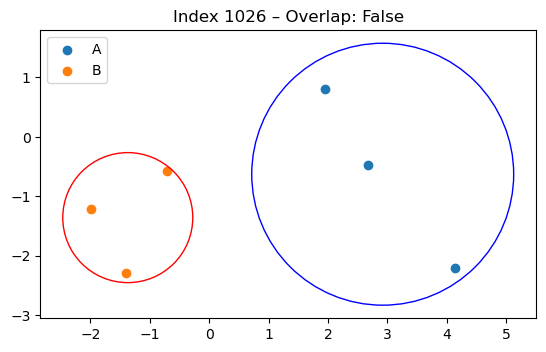

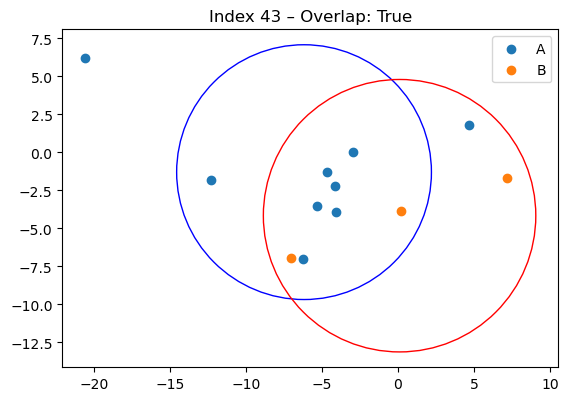

Ergebnis gespeichert in: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv


In [13]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import chi2
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# 1) Pfade anpassen
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\eurasian_otter_all_results_combined.csv'
output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'

# 2) Daten einlesen
df = pd.read_csv(input_csv, dtype=str)

# 3) Parser für Listen-Strings
def parse_list(s):
    if not isinstance(s, str) or not s.strip() or s.strip().lower() == 'nan':
        return np.empty(0, float)
    s2 = s.strip().strip('"').strip("'").strip('[]')
    try:
        lst = ast.literal_eval(f"[{s2}]")
        return np.array(lst, dtype=float)
    except:
        try:
            return np.fromstring(s2, sep=' ')
        except:
            return np.empty(0, float)

# 4) Exakte JMP-Overlap-Funktion (kreisförmig, stdMat[,1])
def compute_overlap_exact(row_idx):
    row = df.iloc[row_idx]
    xa = parse_list(row['coords_a_x']); ya = parse_list(row['coords_a_y'])
    xb = parse_list(row['coords_b_x']); yb = parse_list(row['coords_b_y'])
    if len(xa) < 2 or len(xb) < 2 or len(xa) != len(ya) or len(xb) != len(yb):
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    mu_a = pts_a.mean(axis=0)
    mu_b = pts_b.mean(axis=0)
    cov_a = np.cov(pts_a, rowvar=False)
    cov_b = np.cov(pts_b, rowvar=False)
    # größte Eigenwerte
    lambda1_a = max(np.linalg.eigvalsh(cov_a))
    lambda1_b = max(np.linalg.eigvalsh(cov_b))
    # Radius
    chi_val = np.sqrt(chi2.ppf(0.5, df=2))
    r_a = chi_val * np.sqrt(lambda1_a)
    r_b = chi_val * np.sqrt(lambda1_b)
    center_dist = np.linalg.norm(mu_a - mu_b)
    return center_dist <= (r_a + r_b)

# 5) Parallel berechnen
n_jobs = -1  # alle Kerne nutzen
results = Parallel(n_jobs=n_jobs, prefer="threads")(
    delayed(compute_overlap_exact)(i) for i in range(len(df))
)

df['ellipse_overlap'] = results

# 6) Beispielplots (optional, kann sequentiell laufen)
sample_idxs = df[df['ellipse_overlap'].notna()].sample(3, random_state=42).index
for idx in sample_idxs:
    row = df.loc[idx]
    xa = parse_list(row['coords_a_x']); ya = parse_list(row['coords_a_y'])
    xb = parse_list(row['coords_b_x']); yb = parse_list(row['coords_b_y'])
    pts_a = np.column_stack([xa, ya]); pts_b = np.column_stack([xb, yb])
    mu_a = pts_a.mean(axis=0); mu_b = pts_b.mean(axis=0)
    cov_a = np.cov(pts_a, rowvar=False); cov_b = np.cov(pts_b, rowvar=False)
    lambda1_a = max(np.linalg.eigvalsh(cov_a)); lambda1_b = max(np.linalg.eigvalsh(cov_b))
    chi_val = np.sqrt(chi2.ppf(0.5, df=2))
    r_a = chi_val * np.sqrt(lambda1_a); r_b = chi_val * np.sqrt(lambda1_b)

    fig, ax = plt.subplots()
    ax.scatter(pts_a[:,0], pts_a[:,1], label='A')
    ax.scatter(pts_b[:,0], pts_b[:,1], label='B')
    ax.add_patch(Ellipse(mu_a, 2*r_a, 2*r_a, edgecolor='blue', facecolor='none'))
    ax.add_patch(Ellipse(mu_b, 2*r_b, 2*r_b, edgecolor='red', facecolor='none'))
    ax.set_aspect('equal'); ax.legend()
    ax.set_title(f'Index {idx} – Overlap: {row["ellipse_overlap"]}')
    plt.show()

# 7) Speichern
df.to_csv(output_csv, index=False)
print(f"Ergebnis gespeichert in: {output_csv}")


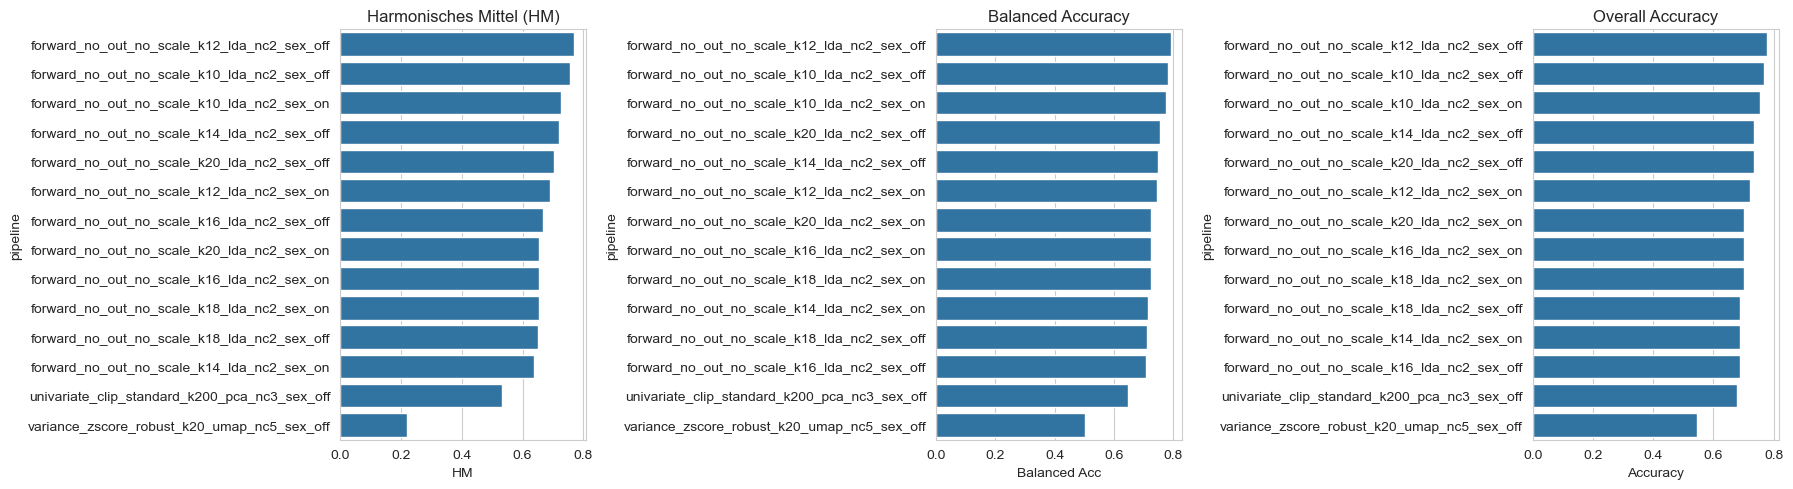

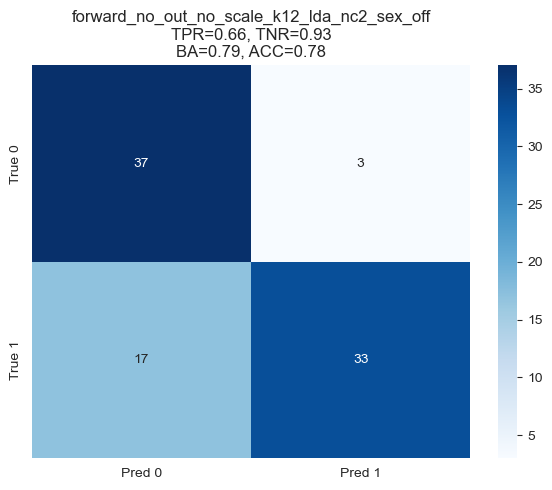

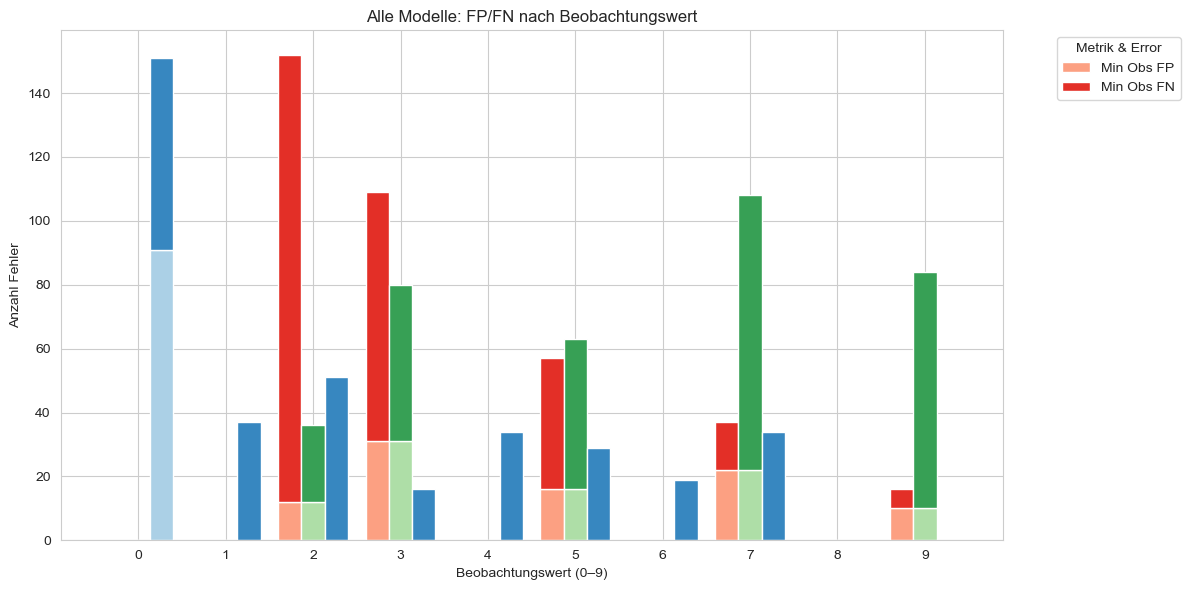

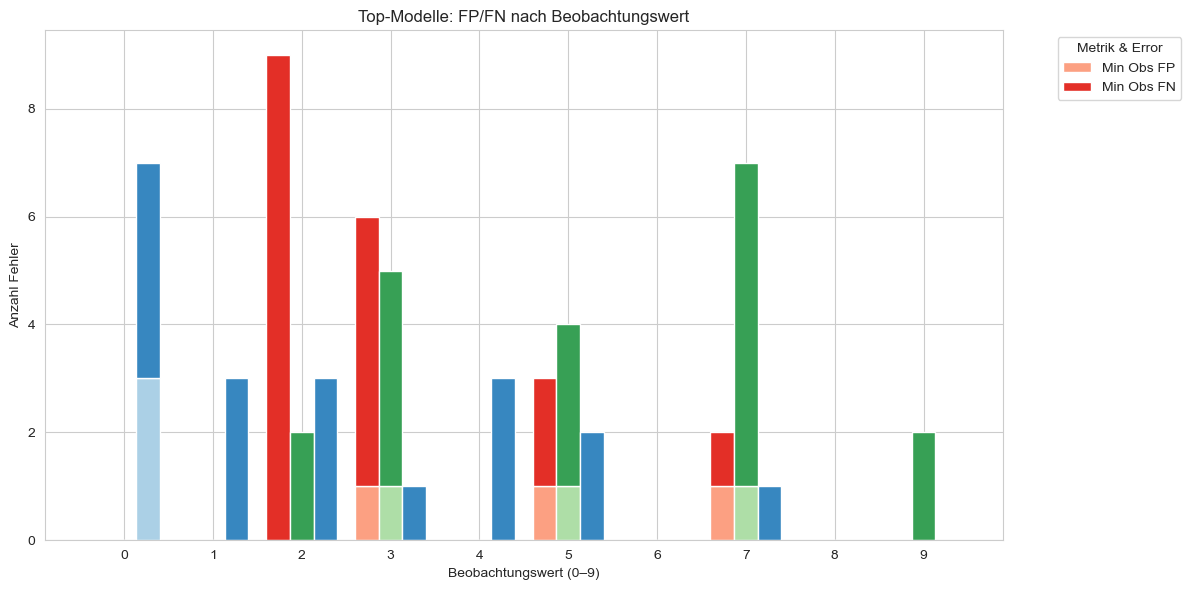

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) Daten laden ---
output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'
df = pd.read_csv(output_csv, dtype=str)

# Ziel und Vorhersage in numerisch
df['same_individual']  = df['same_individual'].map({'True':1,'False':0}).astype(int)
df['ellipse_overlap']  = df['ellipse_overlap'].map({'True':1,'False':0,'0':0,'1':1}).astype(int)

# --- 2) Kennzahlen pro Pipeline berechnen ---
pipelines = df['pipeline'].unique()
metrics = []
for p in pipelines:
    sub    = df[df['pipeline']==p]
    y_true = sub['same_individual']
    y_pred = sub['ellipse_overlap']
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr  = recall_score(y_true, y_pred)
    tnr  = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    acc  = accuracy_score(y_true, y_pred)
    bal  = (tpr + tnr) / 2
    hm   = 2 * (tpr * tnr) / (tpr + tnr) if (tpr + tnr) > 0 else np.nan
    metrics.append({
        'pipeline': p,
        'tpr': tpr,
        'tnr': tnr,
        'accuracy': acc,
        'balanced_accuracy': bal,
        'harmonic_mean': hm
    })
metrics_df = pd.DataFrame(metrics)

# --- 3) Bar-Plots für HM, BA und Overall Accuracy ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    x='harmonic_mean', y='pipeline',
    data=metrics_df.sort_values('harmonic_mean', ascending=False),
    ax=axes[0]
)
axes[0].set_title("Harmonisches Mittel (HM)")

sns.barplot(
    x='balanced_accuracy', y='pipeline',
    data=metrics_df.sort_values('balanced_accuracy', ascending=False),
    ax=axes[1]
)
axes[1].set_title("Balanced Accuracy")

sns.barplot(
    x='accuracy', y='pipeline',
    data=metrics_df.sort_values('accuracy', ascending=False),
    ax=axes[2]
)
axes[2].set_title("Overall Accuracy")

# gemeinsame Legende:
for ax in axes:
    ax.set_xlabel("")  # Labels optional
axes[0].set_xlabel("HM")
axes[1].set_xlabel("Balanced Acc")
axes[2].set_xlabel("Accuracy")

plt.tight_layout()
plt.show()

# --- 4) Top-Pipelines auswählen & Confusion-Matrices plotten ---
best_hm  = metrics_df.loc[metrics_df['harmonic_mean'].idxmax(), 'pipeline']
best_bal = metrics_df.loc[metrics_df['balanced_accuracy'].idxmax(), 'pipeline']
best_acc = metrics_df.loc[metrics_df['accuracy'].idxmax(),        'pipeline']
best_unique = list(dict.fromkeys([best_hm, best_bal, best_acc]))

fig, axes = plt.subplots(1, len(best_unique), figsize=(6*len(best_unique), 5))
if len(best_unique) == 1:
    axes = [axes]

for ax, p in zip(axes, best_unique):
    sub = df[df['pipeline'] == p]
    cm = confusion_matrix(sub['same_individual'], sub['ellipse_overlap'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1']
    )
    m = metrics_df[metrics_df['pipeline'] == p].iloc[0]
    ax.set_title(
        f'{p}\nTPR={m.tpr:.2f}, TNR={m.tnr:.2f}\n'
        f'BA={m.balanced_accuracy:.2f}, ACC={m.accuracy:.2f}'
    )

# Legende für alle CMs (einfacher Platzhalter)
plt.tight_layout()
plt.show()

# --- 5) Fehler-Typ markieren und Observations numeric ---
df['error_type'] = np.where(
    (df['same_individual']==0) & (df['ellipse_overlap']==1), 'FP',
    np.where((df['same_individual']==1) & (df['ellipse_overlap']==0), 'FN', 'OK')
)
df['min_observations'] = df['min_observations'].astype(float).round().astype(int)
df['max_observations'] = df['max_observations'].astype(float).round().astype(int)
df['obs_range']        = (df['max_observations'] - df['min_observations']).astype(int)

errors_all  = df[df['error_type'].isin(['FP','FN'])]
errors_best = errors_all[errors_all['pipeline'].isin(best_unique)]

# --- 6) Kombinierter Stacked-Bar-Plot für alle und Top-Modelle ---
def plot_combined(errors, title, colors):
    # counts per metric & x
    counts = {}
    for metric in ['min_observations','max_observations','obs_range']:
        ct = errors.groupby([metric,'error_type']).size().unstack(fill_value=0)
        ct = ct.reindex(range(0,10), fill_value=0)
        counts[metric] = ct

    labels = {'min_observations':'Min Obs','max_observations':'Max Obs','obs_range':'Range'}
    x = np.arange(0, 10)
    total_width = 0.8
    n_metrics   = 3
    width       = total_width / n_metrics
    offsets     = np.linspace(-total_width/2 + width/2, total_width/2 - width/2, n_metrics)

    plt.figure(figsize=(12,6))
    for i, metric in enumerate(['min_observations','max_observations','obs_range']):
        ct   = counts[metric]
        xpos = x + offsets[i]
        bottom = np.zeros_like(x, dtype=int)
        for et in ['FP','FN']:
            plt.bar(
                xpos, ct.get(et, 0), width=width, bottom=bottom,
                color=colors[metric][et],
                label=f"{labels[metric]} {et}" if i == 0 else ""
            )
            bottom += ct.get(et, 0).values

    plt.xticks(x, x)
    plt.xlabel("Beobachtungswert (0–9)")
    plt.ylabel("Anzahl Fehler")
    plt.title(title)
    # zusammengeführte Legende
    handles, lbls = plt.gca().get_legend_handles_labels()
    by_lbls = dict(zip(lbls, handles))
    plt.legend(by_lbls.values(), by_lbls.keys(), title="Metrik & Error", bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Palettenvarianten (einfach auskommentieren, was gefällt):
# pal_variant1 = {
#    'min_observations': {'FP':'#ff9999','FN':'#cc0000'},
#    'max_observations': {'FP':'#99ff99','FN':'#009900'},
#    'obs_range':        {'FP':'#9999ff','FN':'#0000cc'}
#}
# pal_variant2 = {
#    'min_observations': {'FP':'#fee0d2','FN':'#de2d26'},
#    'max_observations': {'FP':'#c7e9c0','FN':'#238b45'},
#    'obs_range':        {'FP':'#dadaeb','FN':'#3f007d'}
#}
pal_variant3 = {
    'min_observations': {'FP':sns.color_palette("Reds",   2)[0],'FN':sns.color_palette("Reds",   2)[1]},
    'max_observations': {'FP':sns.color_palette("Greens", 2)[0],'FN':sns.color_palette("Greens", 2)[1]},
    'obs_range':        {'FP':sns.color_palette("Blues",  2)[0],'FN':sns.color_palette("Blues",  2)[1]}
}

# Plot für alle Modelle mit gewählter Palette
plot_combined(errors_all,  "Alle Modelle: FP/FN nach Beobachtungswert", pal_variant3)
# Plot für Top-Modelle mit gleicher Palette
plot_combined(errors_best, "Top-Modelle: FP/FN nach Beobachtungswert", pal_variant3)


In [ ]:
# Neuer Notebook-Block: Modellbasierte Vorhersage von „same_individual“ für jede Pipeline

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score
from sklearn.model_selection import GroupKFold

# 1) Datensatz laden
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'
df = pd.read_csv(input_csv, dtype=str)

# 2) Spaltennamen anzeigen
print("Spalten im Datensatz:")
for col in df.columns:
    print(" ", col)

# 3) Ziel und Folds in geeignete Typen bringen
df['same_individual'] = df['same_individual'].map({'True':1,'False':0}).astype(int)
df['fold']            = df['fold'].astype(int)   # angenommen, fold ist numerisch

# 4) Feature-Matrix X und Ziel y definieren
#    Hier kannst du beliebige Spalten zum Droppen anpassen:
drop_cols = [
    'same_individual',  # Ziel
    'pipeline',         # Gruppierungsmerkmal
    'fold',    
    'trail_a_id',
    'trail_b_id',
    'samples_a',
    'samples_b',
    'ind_a',
    'ind_b',
    'coords_a_x',
    'coords_a_y',
    'coords_b_x',
    'coords_b_y',
    'coords_r_x',
    'coords_r_y',
    'mean_mahalanobis_between',
    'median_mahalanobis_between',
    'mean_mahalanobis_within_a',
    'median_mahalanobis_within_a',
    'mean_mahalanobis_within_b',
    'median_mahalanobis_within_b',
    # für Cross-Validation
    # ggf. weitere Spalten, z.B. Koordinaten oder IDs:
    # 'coords_a_x','coords_a_y','coords_b_x','coords_b_y'
]
X = df.drop(columns=drop_cols)
y = df['same_individual']
groups = df['fold']

# 5) Pipeline definieren (StandardScaler + LogisticRegression)
model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# 6) Evaluation pro Pipeline-Wert mit GroupKFold über die Folds
results = []
gkf = GroupKFold(n_splits=df['fold'].nunique())

for pipe_name in df['pipeline'].unique():
    sub_idx = df['pipeline'] == pipe_name
    X_sub = X[sub_idx].astype(float)  # numerische Features
    y_sub = y[sub_idx]
    groups_sub = groups[sub_idx]

    accuracies = []
    bal_accuracies = []
    tprs = []
    tnrs = []

    for train_idx, test_idx in gkf.split(X_sub, y_sub, groups=groups_sub):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y_sub.iloc[train_idx], y_sub.iloc[test_idx]

        model_pipe.fit(X_train, y_train)
        y_pred = model_pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        bal = balanced_accuracy_score(y_test, y_pred)
        tpr = recall_score(y_test, y_pred)  # Sensitivity
        tn  = ((y_test==0) & (y_pred==0)).sum()
        fp  = ((y_test==0) & (y_pred==1)).sum()
        tnr = tn / (tn + fp) if (tn + fp)>0 else np.nan

        accuracies.append(acc)
        bal_accuracies.append(bal)
        tprs.append(tpr)
        tnrs.append(tnr)

    results.append({
        'pipeline': pipe_name,
        'accuracy_mean': np.mean(accuracies),
        'balanced_accuracy_mean': np.mean(bal_accuracies),
        'tpr_mean': np.mean(tprs),
        'tnr_mean': np.mean(tnrs)
    })

results_df = pd.DataFrame(results)
print("\nErgebnisse pro Pipeline:")
display(results_df.sort_values('balanced_accuracy_mean', ascending=False))


Spalten im Datensatz:
  feature_count
  selection_method
  reducer
  n_components
  outlier_method
  scaler_method
  use_sex
  trail_a_id
  trail_b_id
  samples_a
  samples_b
  ind_a
  ind_b
  same_individual
  fold
  pipeline
  k_features
  comparison_id
  min_observations
  max_observations
  use_sexmodel_prediction
  center_a_x
  center_a_y
  center_b_x
  center_b_y
  center_r_x
  center_r_y
  coords_a_x
  coords_a_y
  coords_b_x
  coords_b_y
  coords_r_x
  coords_r_y
  dist_euclidean
  mean_euclidean_between
  median_euclidean_between
  mean_euclidean_within_a
  median_euclidean_within_a
  mean_euclidean_within_b
  median_euclidean_within_b
  dist_manhattan
  mean_manhattan_between
  median_manhattan_between
  mean_manhattan_within_a
  median_manhattan_within_a
  mean_manhattan_within_b
  median_manhattan_within_b
  dist_cosine
  mean_cosine_between
  median_cosine_between
  mean_cosine_within_a
  median_cosine_within_a
  mean_cosine_within_b
  median_cosine_within_b
  dist_chebysh

ValueError: invalid literal for int() with base 10: '0.0'